<a href="https://colab.research.google.com/github/seamusmack/AIML-Resources/blob/main/Session_Notebook_AIML_Movie_Lens_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Python for Data Science: NumPy and Pandas - Week 2</font></center>


<center><img src="https://lajoyalink.com/wp-content/uploads/2018/03/Movie.jpg" width="720"></center>


<center><font size=6> MovieLens Case Study </font></center>

### **Session Agenda**
- Introduction to Numpy and Pandas
- Overview of the datasets
- Getting Familiar with Pandas functions
- Extracting useful insights from the data


### **Context**
The movie rating system that film buffs know today has been around for over 50 years. Over the years, the cultural standards and norms have changed and so have movie ratings. However, even today the process of rating a film remains a closely guarded industry secret.


### **Objective**
MovieLens is a company in the internet and entertainment domain that has an online database of information related to films, television series, online streaming content – including cast, production crew, trivia, ratings, and fan and critical reviews. You have been hired as a Data Scientist for the company. You have been provided with the following three datasets, asked to carry out a detailed analysis of the data, and come up with some meaningful insights which will help the company to address their users in a better way.<br>
<br>
- **movie.csv**: The file contains information related to the movies and their genres. Columns: movie id, movie title, release date, Action, Adventure, Animation, Children’s, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western<br>
- **user.csv**: It contains information about the users who have rated the movies. Columns: user id, age, gender, occupation, zip code<br>
- **ratings.csv**: It contains information for ratings given by the users to a particular movie. Columns: user id, movie id, rating, timestamp<br>
<br>

One of the first steps to carry out any analysis is to import the necessary libraries that will help us to carry out various operations on the data. <br><br>**NumPy, Pandas** are the most widely used python libraries in data science. It provides high-performance, easy to use structures and data analysis tools. <br>So let us first import **NumPy and Pandas** so that we can utilize the functions available in these libraries to analyze our data better.

### **Installing and Importing the Necessary Libraries**

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 -q

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
import pandas as pd
import numpy as np

Now we have imported pandas as pd and numpy as np. Here 'as' is used as an alias.

Let's load all the three datasets using Pandas **read** function so that we can start with our analysis using them

### **Reading the datasets**

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# Reading datasets by using read_csv from pandas package

movie = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/movie.csv")
user = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/user.csv")
ratings = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ratings.csv")

# Quick look at the data
print("Movies:")
print(movie.head())

print("\nUsers:")
print(user.head())

print("\nRatings:")
print(ratings.head())


Movies:
   movie id  movie title release date  Action  Adventure  Animation  \
0         1   Toy Story      1-Jan-95       0          0          1   
1         2   GoldenEye      1-Jan-95       1          1          0   
2         3  Four Rooms      1-Jan-95       0          0          0   
3         4  Get Shorty      1-Jan-95       1          0          0   
4         5     Copycat      1-Jan-95       0          0          0   

   Childrens  Comedy  Crime  Documentary  ...  Fantasy  Film-Noir  Horror  \
0          1       1      0            0  ...        0          0       0   
1          0       0      0            0  ...        0          0       0   
2          0       0      0            0  ...        0          0       0   
3          0       1      0            0  ...        0          0       0   
4          0       0      1            0  ...        0          0       0   

   Musical  Mystery  Romance  Sci-Fi  Thriller  War  Western  
0        0        0        0       0   

In [10]:
print(ratings.columns)


Index(['user id', 'movie id', 'rating', 'timestamp'], dtype='object')


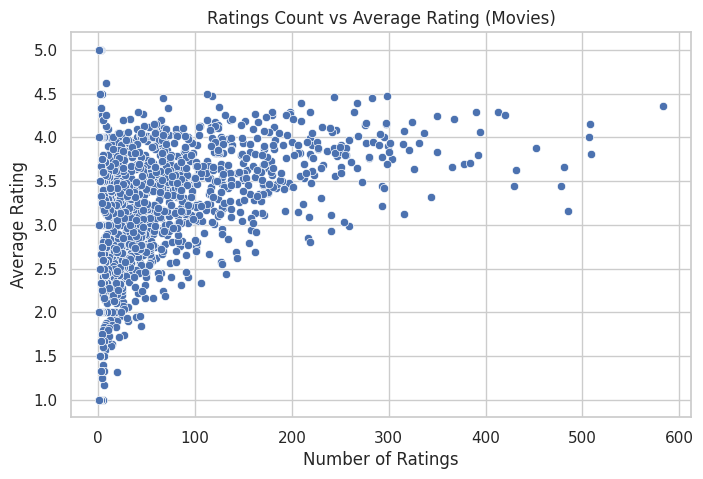

In [11]:
# Clean up any whitespace from column names
ratings.columns = ratings.columns.str.strip()
movie.columns = movie.columns.str.strip()

# Group by 'movie id' — exact match
movie_stats = ratings.groupby('movie id')['rating'].agg(['count', 'mean']).reset_index()
movie_stats.columns = ['movie id', 'rating_count', 'avg_rating']

# Plot ratings count vs avg rating
plt.figure(figsize=(8, 5))
sns.scatterplot(data=movie_stats, x='rating_count', y='avg_rating')
plt.title("Ratings Count vs Average Rating (Movies)")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()



Correlation matrix (ratings only):
            user id  movie id    rating  timestamp
user id    1.000000  0.010377 -0.009371   0.019082
movie id   0.010377  1.000000 -0.189124   0.041867
rating    -0.009371 -0.189124  1.000000  -0.012003
timestamp  0.019082  0.041867 -0.012003   1.000000


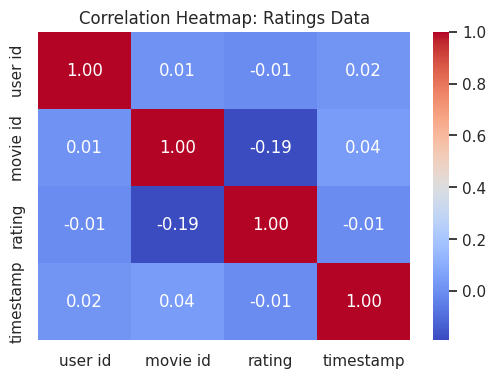

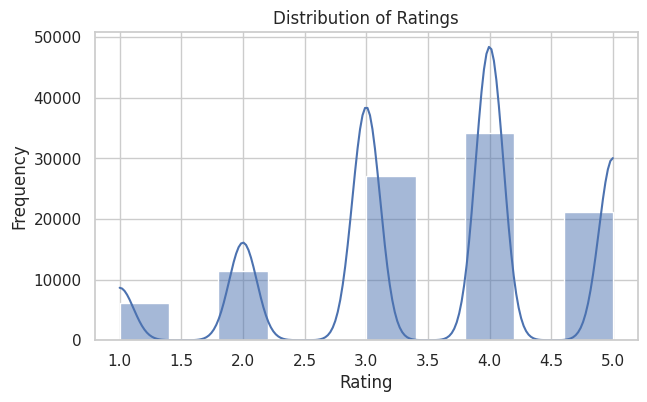

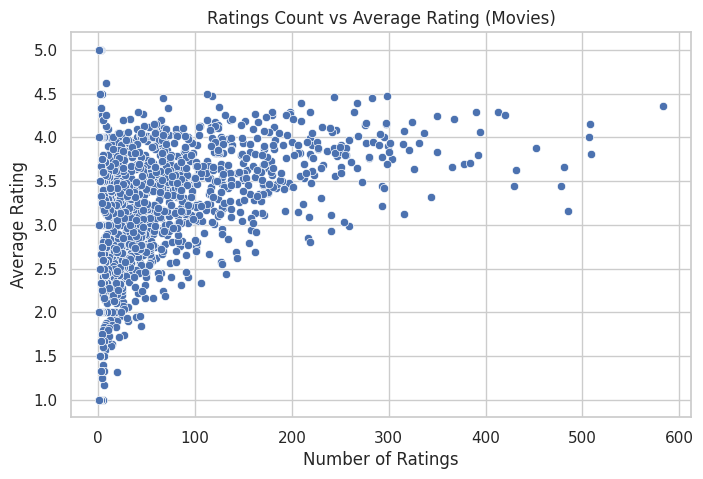

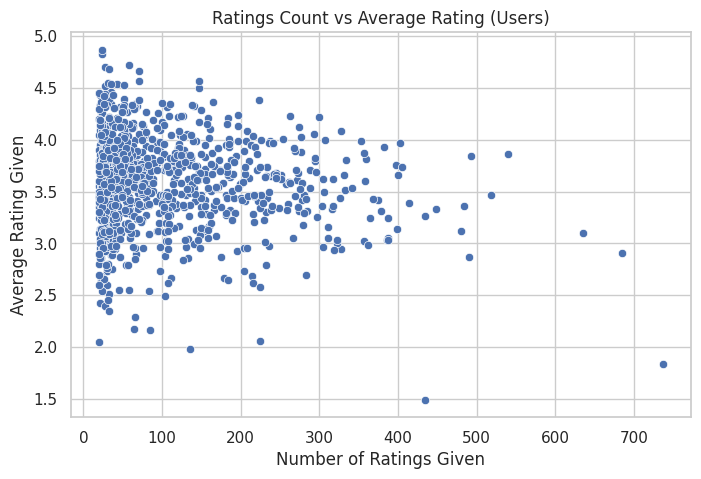

In [12]:
# Clean column names
ratings.columns = ratings.columns.str.strip()
movie.columns = movie.columns.str.strip()
user.columns = user.columns.str.strip()

# --- Correlation on Ratings Dataset ---
print("\nCorrelation matrix (ratings only):")
ratings_corr = ratings.corr(numeric_only=True)
print(ratings_corr)

plt.figure(figsize=(6, 4))
sns.heatmap(ratings_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Ratings Data")
plt.show()

# --- Distribution of Ratings ---
plt.figure(figsize=(7, 4))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# --- Ratings Count vs Average Rating (Movies) ---
movie_stats = ratings.groupby('movie id')['rating'].agg(['count', 'mean']).reset_index()
movie_stats.columns = ['movie id', 'rating_count', 'avg_rating']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=movie_stats, x='rating_count', y='avg_rating')
plt.title("Ratings Count vs Average Rating (Movies)")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

# --- Ratings Count vs Average Rating (Users) ---
user_stats = ratings.groupby('user id')['rating'].agg(['count', 'mean']).reset_index()
user_stats.columns = ['user id', 'rating_count', 'avg_rating']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=user_stats, x='rating_count', y='avg_rating')
plt.title("Ratings Count vs Average Rating (Users)")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Average Rating Given")
plt.grid(True)
plt.show()


### **Data Overview**

The initial steps to understand any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

Let us now delve deeper into each of the datasets individually and understand this aspects well

#### **User Dataset**

#### **Displaying the first 5 rows of the user dataset**

The **head()** function will help us to have a glimpse of the first 5 rows of the dataset

In [ ]:
user.head()

The user dataset has been loaded properly.

- *The user dataset contains demographic information about the users who have rated the movies*
- *The column `gender` has values as M and F, where M represents Male users and F represents Female users*
- *We can also observe that users are from different occupational backgrounds like 'technician', 'writer', etc.*
- *The column `zip code` represents the area where the user is residing*

#### **Understanding the shape of the user dataset**

Let us now check the dimensions of the dataset by using the ***shape*** attribute. <br>

The ***shape*** attribute will help us to get the number of rows and columns of the dataset.<br>

**Knowing the dimensions of the dataframe will help us to understand the number of data points we are working with and proves to be beneficial especially when the dataset is a large one (consisting of a large number of rows and columns).**

In [ ]:
user.shape

- *There are 943 rows and 5 columns in the user dataset.*

#### **Checking the data types of the columns for the user dataset**

Now we are aware of the shape of the dataframe. Let us now have a look at the types of data that we are working with.<br>

The ***info()*** function will help us to understand the data types of the columns.<br>

**Understanding data types ensures that data is stored in the preferred format and the value of each property is as expected.**

In [ ]:
user.info()

- *We can see that the `gender`, `occupation` and `zip code` columns are of object type while the other columns are of integer type since they are containing numbers in them.*
- *The data type of the `zip code` column is object which seems to be wrong and needs further investigation since this column seems to be containing integer values only, as seen from the first 5 rows of the dataframe.*

#### **Getting the statistical summary for the user dataset**

We can now have a look at the statistical summary of the dataset.<br>

The **describe()** function will help us in finding out the statistical summary.<br>

**The statistical summary will give us a overview of the numerical columns of the data and display various features like the minimum, maximum, mean, standard deviation, etc. of the columns. This will help us to understand the distribution of the values present in the numerical columns.**

In [ ]:
user.describe()

- *We can see from the `age` column that the average age of users who have rated the movies is 34 years*
- *The age of users ranges from 7 years (min or minimum) to 73 years (max or maximum)*
- *Since user id is an unique identifier of the users who have rated the movies, interpreting its summary statistics won't yield meaningful insights.*

Now we have somewhat got a basic idea of the user dataset. Let us now carry out similar operations on the other two datasets and try to find out relevant information from them as well.

#### **Movie Dataset**

#### **Displaying the first 5 rows of the movie dataset**

In [ ]:
movie.head()

- *As we can see the 'movie' dataset contains information related to the movies and their genres. While `movie id`, `movie title`, and `release date` are information related to the movies, the rest of the columns are specifically the genres of the movies.*<br>
- *The columns associated to the genres of the movies are having values of 0s and 1s. The value '1' means that a particular movie belongs to that genre while the value '0' represents that the movie is not a part of that genre.*
- *We can also see that a movie can have multiple genres as there are more than one column that are having value as '1' for a particular movie in the columns associated with genres.*<br>
- *For example, the movie named 'Toy Story' is having genres as 'Animation', 'Childrens', and 'Comedy'.*

#### **Understanding the shape of the movie dataset**

In [ ]:
movie.shape

- *There are 1680 rows and 21 columns in the movie dataset.*

#### **Checking the data types of the columns for the movie dataset**

In [ ]:
movie.info()

- *We can see that the `movie title` and `release date` columns are of object type since these columns are having some text in them.*
- *All the other columns are of integer type since they are containing numbers in them.*

#### **Getting the statistical summary for the movie dataset**

In [ ]:
movie.describe()

- *The statistical summary of the `movie_id` column will not yield meaningful insights as it is a unique identifier of each of the movies. The statistical summary of the columns related to genres is also not much helpful since these columns consists of only 0s and 1s values.*

We have now explored the movie dataset as well. Let us now finally see the ratings dataframe

#### **Ratings**

#### **Displaying the first 5 rows of the ratings dataset**

In [ ]:
ratings.head()

The ratings dataset has also been imported properly without any errors

- *The ratings dataframe contains information about the ratings given by the users to a particular movie.*

#### **Understanding the shape of the ratings dataset**

In [ ]:
ratings.shape

- *There are 100000 rows and 4 columns in the ratings dataset. This is quite a large dataset as compared to the previous two dataframes.*

#### **Checking the data types of the columns for the ratings dataset**

In [ ]:
ratings.info()

- *Here all the columns are of integer data type since they contain numbers in them.*

#### **Getting the statistical summary for the ratings dataset**

In [ ]:
ratings.describe()

- *The numbers for the `timestamp` column do not convey any meaningful insights. However, from the `rating` column, we can see that the average rating of all the movies is around 3.53 while  the ratings ranges from 1 to 5.*

By now we have considerable idea about the datasets we are working with. It's time to dig deeper and find out answers to some important questions that will help us get a better idea about the industry.<br>


***Let's extract some meaningful insights from the data by answering a few business-oriented questions***

<h1><font size=6>How many movies belong to a particular genre?</font></h1>

We had seen earlier that a particular movie can have multiple genres. So let us investigate on this more.<br>

**But do you remember which dataset contains information about genres of movies ???**

*Yes*, movie dataset does contains this information. So let's try to have look on that

In [ ]:
movie.head()

Let's analyze this dataset using some Pandas Functions

### **Pandas Functions**

#### **Getting all the columns of the movie dataset**

Let us print all the columns of the movie dataset so that we can get a better idea about what all genres are there

In [8]:
movie.columns

Index(['movie id', 'movie title', 'release date', 'Action', 'Adventure',
       'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance',
       'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')

- *We can see that all the columns starting from 'Action' to 'Western' are columns that are related to the genres of the movies.*

Since there are many genres present in this dataset, let's create a variable to store all these values as a list so that we can use it for further analysis.

In [13]:
genres = ['Action', 'Adventure',
       'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance',
       'Sci-Fi', 'Thriller', 'War', 'Western']

In [14]:
# using the len() function to calculate the number of genres
print('The number of genres present in the movie dataset are ', len(genres))

The number of genres present in the movie dataset are  18


- ***There are 18 genres in total.***

One of the way to find the answer is to take all the genre columns and find the sum for each column. Here, instead of writing the genre columns again, we will use the 'genres' list.

In [ ]:
# printing the genres list
genres

In [ ]:
movie[genres].sum()

,0
Action,251
Adventure,135
Animation,42
Childrens,122
Comedy,505
Crime,109
Documentary,50
Drama,725
Fantasy,22
Film-Noir,24


- *Here, we can see that 'Action' genre has 251 movies, 'Adventure' genre has 135 movies and so on. However it would have been far better if we had a series where the numbers were arranged in ascending or descending order so that we could have easily found out the genres with the highest and lowest number of movies.* <br>

This can be achieved by simply using the **sort_values()** function to arrange the numbers in descending or ascending order.

**sort_values() Function**<br>
Pandas sort_values() function sorts a data frame in Ascending or Descending order of passed Column. It’s different than the sorted Python function since it cannot sort a data frame and particular column cannot be selected.

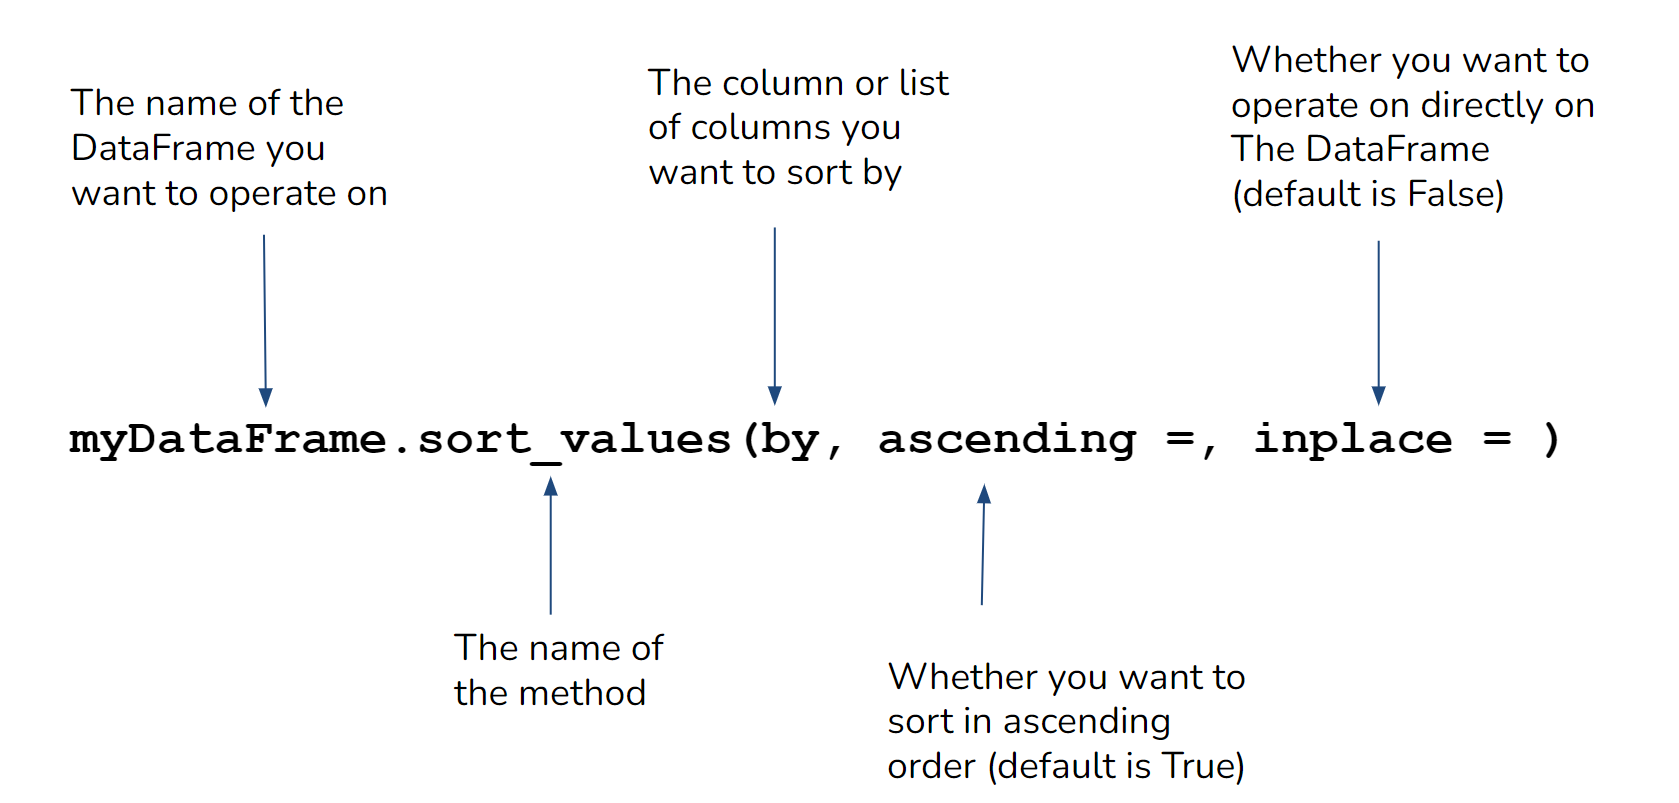

In [ ]:
movie[genres].sum().sort_values(ascending = False) #ascending= False will sort the values in descending order. By default the parameter ascending is set to True

,0
Drama,725
Comedy,505
Thriller,251
Action,251
Romance,247
Adventure,135
Childrens,122
Crime,109
Sci-Fi,101
Horror,92


<h1><font size=5>Insights</font></h1>


- *Movies are distributed across 18 genres in total*
- *We can observe that 'Drama' genre has the highest number of movies with 725 in total followed by 'Comedy' at 505*
- *The top five genres with the highest number of movies are 'Drama', 'Comedy', 'Action', 'Thriller', and 'Romance'*
- *'Fantasy' genre has the lowest number of movies (22 in count)*

<h1><font size=6>Can we find the movies that have more than one genre?</font></h1>

As discussed earlier a particular movie can have more than one genre, so to answer the above problem we can use the below steps:


- The basic approach to find out this information will be to add a new column to the movie dataframe that will contain the summation of 1's from the genre columns along the row for a particular movie
- After this we can find out the number of movies that have more than one genre by simply picking up the rows where the added new column is having a value of more than 1

So, let us create a new column named `Number of Genres` and add it to the dataframe.

In [ ]:
movie["Number of Genres"] = movie.loc[:, genres].sum(axis=1)

- *The above code adds a new column named `Number of Genres` to the dataframe. This new column consists the summation of 1s from the genre columns along the row for a particular movie*<br>
- *movie.loc[:, genres] - This is picking up all the rows and the columns that are present in the genres list*
- *The axis = 1 parameter is used to get the summation of the values along the row while axis = 0 is used to get the summation of the values along the column*

Now let us print the head of the movie column and see whether the new column has been added or not.

In [ ]:
movie.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,Number of Genres
0,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,3
1,2,GoldenEye,1-Jan-95,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3
2,3,Four Rooms,1-Jan-95,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,4,Get Shorty,1-Jan-95,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3
4,5,Copycat,1-Jan-95,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,3


- *As we can see a new column named `Number of Genres` has been added at the end of the dataframe*

Now let us pick up the rows where `Number of Genres`>1 so that we can find the number of movies with more than 1 genre

In [ ]:
movie[movie['Number of Genres']>1] #this will subset the data as per the given condition

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,Number of Genres
0,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,3
1,2,GoldenEye,1-Jan-95,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3
3,4,Get Shorty,1-Jan-95,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3
4,5,Copycat,1-Jan-95,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,3
6,7,Twelve Monkeys,1-Jan-95,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1666,1669,MURDER and murder,20-Jun-97,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,3
1667,1670,Tainted,1-Feb-98,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,2
1670,1673,Mirage,1-Jan-95,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,2
1676,1679,B. Monkey,6-Feb-98,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,2


Let us print the shape of this dataframe so that we know the number of movies that are having more than one genre.

In [ ]:
movie[movie['Number of Genres']>1].shape

(849, 22)

- *There are 849 movies that are having more than one genre.*

In [ ]:
movie.shape

(1680, 22)

In [ ]:
# DF Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
ratings_corr = ratings.corr(numeric_only=True)
print(ratings_corr)

# Heatmap visualization
plt.figure(figsize=(6, 4))
sns.heatmap(ratings_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔷 Correlation Heatmap - Ratings Data")
plt.show()

In [ ]:
# Ratings Distribution

plt.figure(figsize=(7, 4))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title("📊 Distribution of Ratings")
plt.xlabel("Rating Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
# Movie Popularity vs Average Rating

movie_stats = ratings.groupby('movie id')['rating'].agg(['count', 'mean']).reset_index()
movie_stats.columns = ['movie id', 'rating_count', 'avg_rating']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=movie_stats, x='rating_count', y='avg_rating')
plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

- *The original movie dataset contained 1680 movies. So out of 1680 movies, 849 i.e around 50% of the movies are having more than one genre.*

<h1><font size=5>Insights</font></h1>


- *Out of 1680 movies, 849 movies comprising around 50% are having more than one genre and 831 movies have only single genre*
- *This shows that we have an almost equal ratio (50:50) of movies having more than one genre and having single genre*

<font size=6 color='blue'>Poll Question 1</font>

We want to find all movies that belong to more than one genre using different indexing methods. Below are two approaches:

Code 1:
```
movie["Number of Genres"] = movie.loc[:, genres].sum(axis=1)
```

Code 2:
```
movie["Number of Genres"] = movie.iloc[:, 3:].sum(axis=1)

```

**Which of the following statements is TRUE about these two approaches?**

> A) Code 1 is incorrect because .loc cannot be used for numerical operations.

 >B) Code 2 is incorrect because .iloc cannot perform conditional filtering on DataFrames.

> C) Both codes will return the same result but use different indexing methods.

> D) Both codes are incorrect because sum() cannot be used on a subset of columns.



In [ ]:
# this cell can be used for running the code and validating the output


<font size=6 color='blue'>Poll Question 2</font>

We want to display only the ID, title, release date, and number of genres in the movies in the dataset.

**Which of the following can help us get the same?**

> A) `movie.loc[["movie id",	"movie title", "release date", "Number of Genres"]]`

> B) `movie.iloc[:, ["movie id",	"movie title", "release date", "Number of Genres"]]`

> C) `movie.iloc[:, [0, 1, 2, -1]]`

> D) `movie.iloc[:, [1, 2, 3, -1]]`

In [ ]:
# this cell can be used for running the code and validating the output


<h1><font size=6>Can we find the genres that are most liked by the users?</font></h1>


*As we have already seen that the information regarding the ratings is present in the ratings dataset, however, the genre columns are present in the movie dataset. The only column connecting this two datasets is the movie id column. We can `merge` both the datasets on the basis of common variable that is `movie_id`.*

**Merge/Join / Concatenation**<br>
Pandas provide various facilities for easily combining together Series or DataFrame with various kinds of set logic for the indexes and relational algebra functionality in the case of join / merge-type operations.<br> <br>Here are the different types of the Joins:<br>

**Inner Join**: Returns records that have matching values in both tables<br>

<img src = "https://i.ibb.co/RD73qtW/inner.png">

**Left Join**: Returns all records from the left table, and the matched records from the right table<br>

<img src= "https://i.ibb.co/72ngdJ1/left.png" >


**Right Join**: Returns all records from the right table, and the matched records from the left table<br>

<img src="https://i.ibb.co/yPG1qb9/right.png">

**Outer/Full Join**: Returns all records when there is a match in either left or right table

<img src= "https://i.ibb.co/vc5MCfV/outer.png">

In [ ]:
df_merge = movie.merge(ratings, on = 'movie id', how = 'inner')
df_merge.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,Number of Genres,user id,rating,timestamp
0,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,308,4,887736532
1,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,287,5,875334088
2,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,148,4,877019411
3,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,280,4,891700426
4,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,66,3,883601324


- *As we can see that the `user id`, `rating`, `timestamp` columns are added at the end of the dataframe*

In order to find the genres which are most liked by the users, we can find the average ratings of each of the genre and then compare among them.
<br>
For this we can use the `genres` list

In [ ]:
genres

['Action',
 'Adventure',
 'Animation',
 'Childrens',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

We will run a loop across the merged dataframe for the columns that are present in the genres list. Whenever a particular genre is found to be have '1' value in its column, the rating corresponding to that '1' value will be extracted and in this end we will calculate the average value of all this extracted ratings for a particular genre.

In [ ]:
for i in genres:
    print(i,':' , df_merge[df_merge[i]==1].rating.mean())

Action : 3.480245417953027
Adventure : 3.503526503308369
Animation : 3.5766990291262135
Childrens : 3.3532442216652742
Comedy : 3.3940734781442745
Crime : 3.6322780881440098
Documentary : 3.6728232189973613
Drama : 3.6873793708484772
Fantasy : 3.2152366863905324
Film-Noir : 3.9215233698788228
Horror : 3.2903893172841827
Musical : 3.521396851029471
Mystery : 3.63813155386082
Romance : 3.621704948358255
Sci-Fi : 3.5607227022780834
Thriller : 3.5090069495245064
War : 3.815811874866993
Western : 3.6132686084142396


<h1><font size=5>Insights</font></h1>


- *'Film-Noir' genre is having the highest average ratings with an average rating of 3.92 followed by 'War' genre with rating of 3.81*
- *'Fantasy' genre is having the lowest average ratings with an average rating of 3.21*
- *Among 18 genres, only 5 genres have received a rating below 3.5 which means around 72% of genres are rated above average*

<font size=6 color='blue'>Poll Question 3</font>

**Which of the following code snippets correctly retrieves information for ONLY those users who have rated movies?**

> A)
```
df_merge = movie.merge(ratings, on = 'movie id', how = 'outer')
df_merge.head()
```

> B)
```
df_merge = user.merge(ratings, on = 'user id', how = 'inner')
df_merge.head()
```

> C)
```
df_merge = user.merge(movie, on = 'movie id', how = 'inner')
df_merge.head()
```

> D)
```
df_merge = movie.merge(ratings, on = 'user id', how = 'outer')
df_merge.head()
```

In [ ]:
# this cell can be used for running the code and validating the output

Till now we have done analyses on the genres and movies and generated some insights.

<h1><font size=6>Can we find which movies have been most preferred by the users?</font></h1>

Let's start by checking the top rated movies by the users.
As we already know that `movie` and `ratings` datasets has the information related to the ratings of the movies. <br>
Therefore, we can *merge* both the datasets on the basis of common variable that is `movie_id` and get the average ratings for all the movies. Since we have already merged these datasets before, we can call it again to get the values

In [ ]:
df_merge.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,Number of Genres,user id,rating,timestamp
0,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,308,4,887736532
1,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,287,5,875334088
2,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,148,4,877019411
3,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,280,4,891700426
4,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,0,0,0,0,3,66,3,883601324


- *The datasets has been merged successfully and the columns has been added at the end of the dataset*

We can notice that multiple rating has been given to a single movie from different users.

**To find out movies preferred by users we need to first get the average ratings of each movie** <br><br> We can perform this by using *group_by* function from Pandas

**Groupby Function**<br>
Pandas’ *GroupBy* is a powerful and versatile function in Python. It allows you to split your data into separate groups to perform computations for better analysis.*GroupBy* allows us to group our data based on different features and get a more accurate idea about your data.

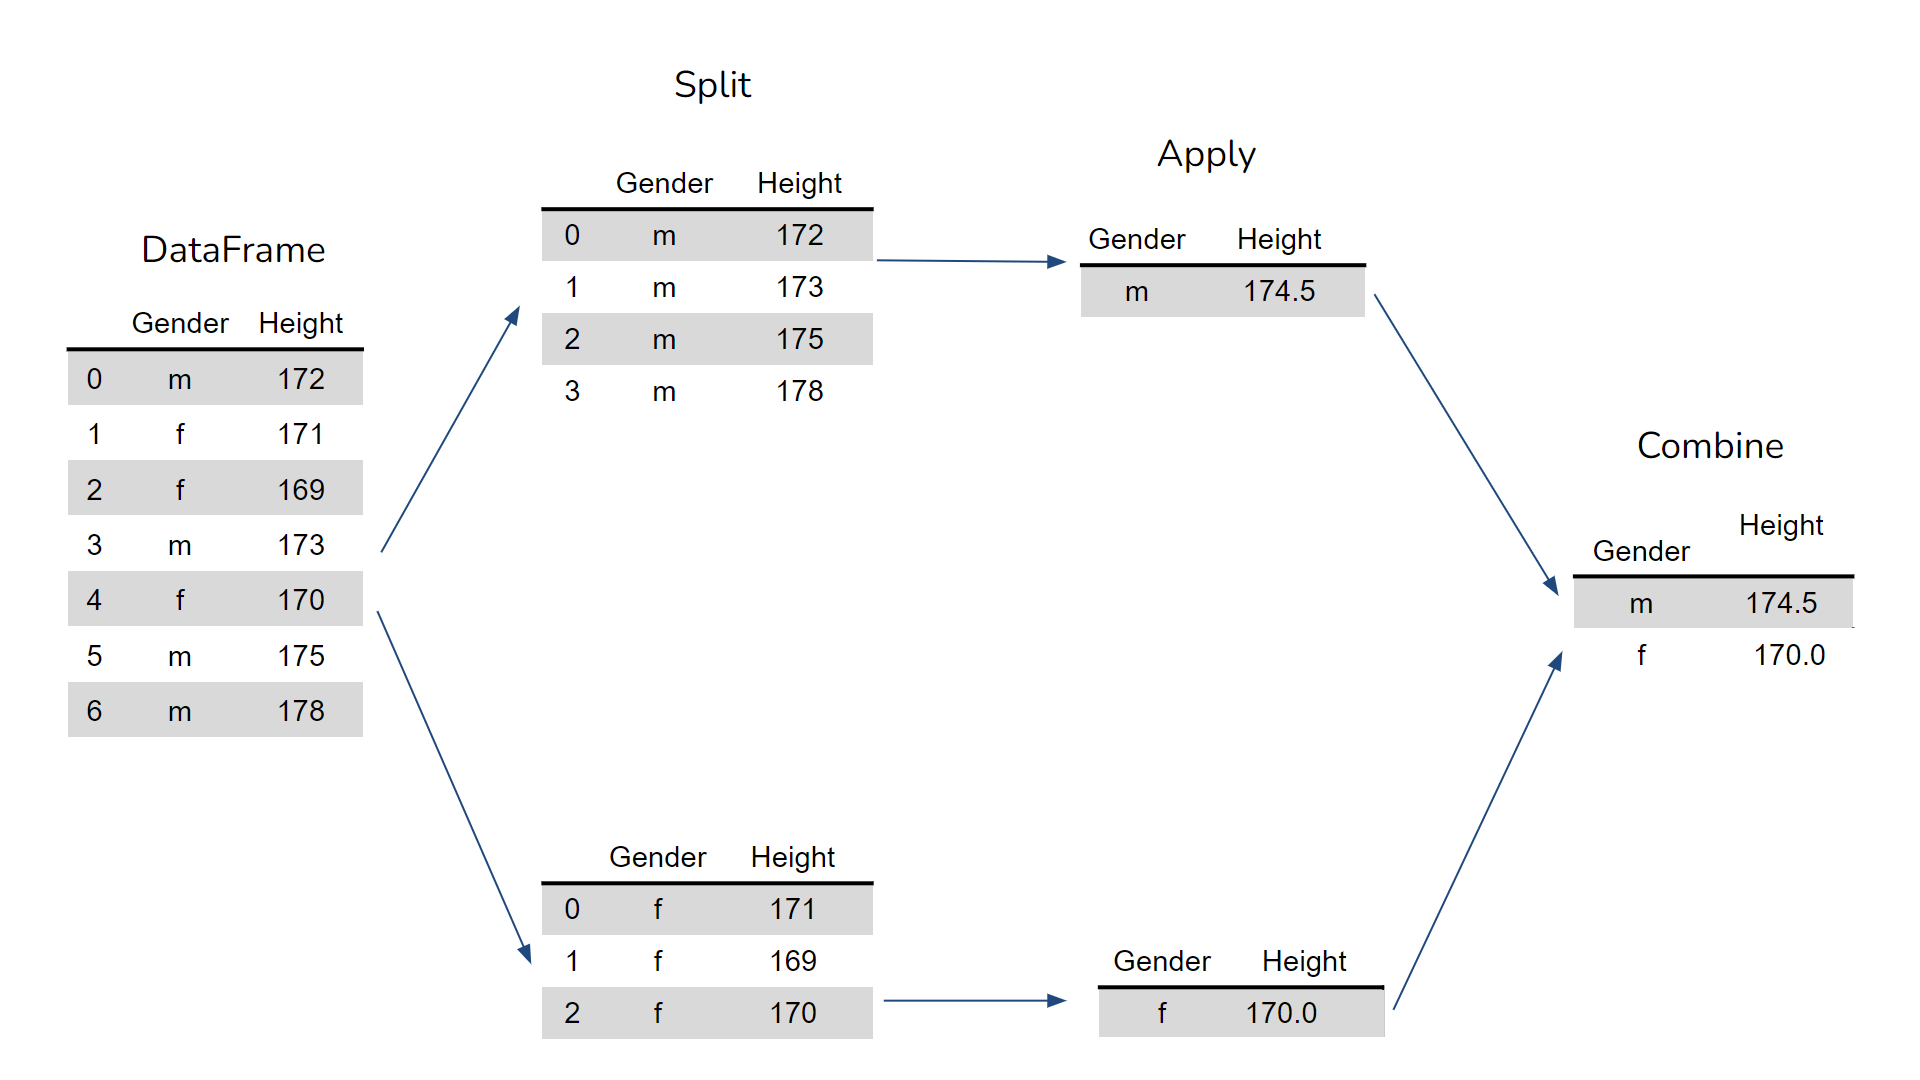

Now let's apply the groupby function to our datasets:

In [ ]:
avg_rating = df_merge.groupby(['movie title'])[['rating']].mean().reset_index() # reset_index will reset the index of dataframe to default indexing (0 to number of rows minus 1)
avg_rating

,movie title,rating
0,'Til There Was You,2.333333
1,1-900,2.600000
2,101 Dalmatians,2.908257
3,12 Angry Men,4.344000
4,187,3.024390
...,...,...
1652,Young Guns,3.207921
1653,Young Guns II,2.772727
1654,"Young Poisoner's Handbook, The",3.341463
1655,Zeus and Roxanne,2.166667


*This displays the average rating for all the movies.* <br><br>
Let's rename the `rating` column to `Avg_rating` for better understanding



In [ ]:
avg_rating.rename(columns={'rating':'Avg_rating'},inplace=True)
avg_rating.head()

,movie title,Avg_rating
0,'Til There Was You,2.333333
1,1-900,2.600000
2,101 Dalmatians,2.908257
3,12 Angry Men,4.344000
4,187,3.024390


We can also sort them in a descending or ascending order by using *sort_values* function
<br>**Let's check the movies with highest average ratings**

In [ ]:
avg_rating.sort_values(ascending=False, by= 'Avg_rating')

,movie title,Avg_rating
30,Aiqing wansui,5.0
1170,Prefontaine,5.0
631,"Great Day in Harlem, A",5.0
1354,Someone Else's America,5.0
1382,Star Kid,5.0
...,...,...
482,"Eye of Vichy, The (Oeil de Vichy, L')",1.0
1604,Wend Kuuni (God's Gift),1.0
1648,Yankee Zulu,1.0
1640,"Woman in Question, The",1.0


In [ ]:
avg_rating[avg_rating['Avg_rating']==5] #it will subset the data as per the specified condition

,movie title,Avg_rating
30,Aiqing wansui,5.0
461,Entertaining Angels: The Dorothy Day Story,5.0
631,"Great Day in Harlem, A",5.0
942,Marlene Dietrich: Shadow and Light (,5.0
1170,Prefontaine,5.0
1270,"Saint of Fort Washington, The",5.0
1274,Santa with Muscles,5.0
1354,Someone Else's America,5.0
1382,Star Kid,5.0
1466,They Made Me a Criminal,5.0


<h1><font size=5>Insights</font></h1>


- *We can observe movies like **Great Day in Harlem, A, Prefontaine** etc are top rated movies*
- *Movies like **Shadow of Angels (Schatten der Engel), Power 98**, etc are least rated*
- *There are 10 movies which have been rated as 5.0*

But we know there are movies which are rated more than once by different users, and hence this may affect the overall rating of the movie.

<h1><font size=6>So can we find which movies are rated most of the times?</font></h1>

Let's create a variable which contains the movies with their ratings count

In [ ]:
movie_count = df_merge.groupby(['movie title'])['rating'].count().reset_index()
movie_count

,movie title,rating
0,'Til There Was You,9
1,1-900,5
2,101 Dalmatians,109
3,12 Angry Men,125
4,187,41
...,...,...
1652,Young Guns,101
1653,Young Guns II,44
1654,"Young Poisoner's Handbook, The",41
1655,Zeus and Roxanne,6


We can again rename the `rating` column to `Rating_counts` and sort them in descending order to display highest to lowest count of ratings

In [ ]:
movie_count.rename(columns={'rating':'Rating_counts'},inplace=True)
movie_count.head()

,movie title,Rating_counts
0,'Til There Was You,9
1,1-900,5
2,101 Dalmatians,109
3,12 Angry Men,125
4,187,41


In [ ]:
movie_count.sort_values(ascending=False, by= 'Rating_counts')

,movie title,Rating_counts
1393,Star Wars,583
332,Contact,509
497,Fargo,508
1232,Return of the Jedi,507
858,Liar Liar,485
...,...,...
1576,"Very Natural Thing, A",1
1587,"Walk in the Sun, A",1
1088,Office Killer,1
1123,Paris Was a Woman,1


- *We can observe that **Star Wars** has been rated most number of times (**583 times**) and there are few movies which have least rating counts like **Paris Was a Woman	,Á köldum klaka (Cold Fever)**.*

There are other movies which are mostly rated by users, so let's check movies which are rated more than 100 times

In [ ]:
movie_100 = movie_count[movie_count['Rating_counts']>100] #this will subset the dataset 'movie_count' as per the specified condition
movie_100

,movie title,Rating_counts
2,101 Dalmatians,109
3,12 Angry Men,125
7,2001: A Space Odyssey,259
15,Absolute Power,127
16,"Abyss, The",151
...,...,...
1627,Willy Wonka and the Chocolate Factory,326
1638,"Wizard of Oz, The",246
1646,"Wrong Trousers, The",118
1651,Young Frankenstein,200


*There are 334 movies which are rated more than 100 times by the users*

Among these movies, let's find out **which movies has been top rated by customers** so that we can know what kind of movies are preferred by users mostly

In [ ]:
avg_rating.head()

,movie title,Avg_rating
0,'Til There Was You,2.333333
1,1-900,2.600000
2,101 Dalmatians,2.908257
3,12 Angry Men,4.344000
4,187,3.024390


In [ ]:
movie_100.head()

,movie title,Rating_counts
2,101 Dalmatians,109
3,12 Angry Men,125
7,2001: A Space Odyssey,259
15,Absolute Power,127
16,"Abyss, The",151


We can merge both the datasets, and have a combined view on the basis of Average rating and rating counts

In [ ]:
df_top = avg_rating.merge(movie_100, on = 'movie title', how = 'inner')
df_top

,movie title,Avg_rating,Rating_counts
0,101 Dalmatians,2.908257,109
1,12 Angry Men,4.344000,125
2,2001: A Space Odyssey,3.969112,259
3,Absolute Power,3.370079,127
4,"Abyss, The",3.589404,151
...,...,...,...
329,Willy Wonka and the Chocolate Factory,3.631902,326
330,"Wizard of Oz, The",4.077236,246
331,"Wrong Trousers, The",4.466102,118
332,Young Frankenstein,3.945000,200


In [ ]:
df_top.sort_values(ascending=False, by='Avg_rating').head(25) #display top 25 movies on the basis of average rating

,movie title,Avg_rating,Rating_counts
63,"Close Shave, A",4.491071,112
260,Schindler's List,4.466443,298
331,"Wrong Trousers, The",4.466102,118
54,Casablanca,4.456790,243
269,"Shawshank Redemption, The",4.445230,283
248,Rear Window,4.387560,209
319,"Usual Suspects, The",4.385768,267
291,Star Wars,4.358491,583
1,12 Angry Men,4.344000,125
59,Citizen Kane,4.292929,198


Similarly we can sort them as per the ratings counts also

In [ ]:
df_top.sort_values(ascending=False, by='Rating_counts').head(25) #display top 25 movies on the basis of rating counts

,movie title,Avg_rating,Rating_counts
291,Star Wars,4.358491,583
69,Contact,3.803536,509
107,Fargo,4.155512,508
251,Return of the Jedi,4.007890,507
178,Liar Liar,3.156701,485
99,"English Patient, The",3.656965,481
261,Scream,3.441423,478
309,Toy Story,3.878319,452
8,Air Force One,3.631090,431
159,Independence Day (ID4),3.438228,429


<h1><font size=5>Insights</font></h1>


- *There are 334 movies in total which have received ratings more than 100 times*
- *As per the average rating, **Close Shave, A** has maximum average rating with a rating count of 112*
- *As per the rating counts, **Star Wars** has received maximum number counts with an average rating of 4.35*
- *There are few movies which have least rating counts like Paris Was a Woman	,Á köldum klaka (Cold Fever)*

Since we have extracted the top rated movies with most number of ratings given by users.

<h1><font size=6>Can we extract some relationship between demographic details of the users and ratings for the movies?</font></h1>

****



All the datasets can be used to identify the demography of the users. Therefore, we will merge all the datasets together and perform the analysis

Since we have already merged datasets `rating` and `movie` in a variable `df_merge`, therefore we can merge the dataset `user` with this dataset

In [ ]:
# Merging user dataset with movie and ratings(already merged : df_merge) dataset
df_merge_all = df_merge.merge(user, on = 'user id', how = 'inner')

In [ ]:
df_merge_all.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,War,Western,Number of Genres,user id,rating,timestamp,age,gender,occupation,zip code
0,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,3,308,4,887736532,60,M,retired,95076
1,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,3,287,5,875334088,21,M,salesman,31211
2,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,3,148,4,877019411,33,M,engineer,97006
3,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,3,280,4,891700426,30,F,librarian,22903
4,1,Toy Story,1-Jan-95,0,0,1,1,1,0,0,...,0,0,3,66,3,883601324,23,M,student,80521


**Let's check on various attributes of the users in order to know the preferences for the movies and their genres**

In [ ]:
user['gender'].value_counts(normalize=True) #this will give the proportion of males and females users extracted from User dataset

,proportion
gender,
M,0.710498
F,0.289502


In [ ]:
df_merge_all.groupby('gender').rating.mean() #grouping the dataset on 'gender' column and taking the average of ratings

,rating
gender,
F,3.531510
M,3.529333


- *The average rating given by Males and Females is almost equal with a value of around 3.53*

In [ ]:
df_merge_all.groupby('occupation').rating.mean().sort_values(ascending= False) #grouping the dataset on 'occupation' column and taking the average of ratings.

,rating
occupation,
none,3.777778
lawyer,3.735316
doctor,3.688889
educator,3.670692
artist,3.653380
administrator,3.635646
scientist,3.611273
salesman,3.582944
programmer,3.568205


- *Users who are not working have given highest ratings as compared to users who are working professionals*
- *Healthcare workers have given lowest ratings on an average*

<font size=6 color='blue'>Poll Question 4</font>

**Which of the following code snippets will allow us to analyze user behavior based on their occupation and gender?**

> A) `df_merge_all.groupby().rating.mean(['occupation','gender'])`

> B) `df_merge_all.groupby('occupation','gender').rating.mean()`

> C) `df_merge_all[['occupation','gender']].groupby(['occupation','gender']).rating.mean()`

> D) `df_merge_all.groupby(['occupation','gender']).rating.mean()`

In [ ]:
# this cell can be used for running the code and validating the output


<h1><font size=5>Insights</font></h1>


- *Around 71% of users are Males while only 29% users are females*
- *The average rating given by Males and Females is almost equal with a value of around 3.53*
- *Users who are not working have given highest ratings as compared to users who are working professionals*
- *Healthcare workers have given lowest ratings on an average*
- *The low ratings from the healthcare sector is majorly driven by female workers*
- *Only male doctors have given ratings. No female doctors have given ratings as per the observations*

### **Executive Summary**

- *Movies are distributed across 18 genres in total*
- *The top five genres with the highest number of movies are 'Drama', 'Comedy', 'Action', 'Thriller', and 'Romance'*
- *Out of 1680 movies, 50% of the movies have more than one genre, while the rest have a single genre*
- The *'Film-Noir' genre has the highest average ratings with an average rating of 3.92, while the 'Fantasy' genre has the lowest average ratings with an average rating of 3.21*
- *Among 18 genres, 72% of the genres are rated above average 3.5*
- *Movies like **Great Day in Harlem, A**, **Prefontaine**, etc. are top-rated movies, while movies like **Shadow of Angels (Schatten der Engel)**, **Power 98**, etc. are least rated*
- *There are 334 movies in total which have been rated more than 100 times*
- *The movie **Close Shave, A** has the highest average rating and was rated 112 times, while the **Star Wars** movie received the highest number of ratings with an average rating of 4.35*
- *Around 71% of users are Males while only 29% users are females*
- *The average rating given by Males and Females is almost equal with a value of around 3.53*
- *Users who are not working have rated movies higher compared to users who are working professionals*
- *Healthcare workers have given the lowest ratings on an average*

<font size=6 color="blue">Power Ahead!</font>
___